In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the data
df = pd.read_csv('Flight_delay.csv.zip')
df.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [ ]:
#selecting the columns
df = df[['DayOfWeek','Date','DepTime','Airline','Origin','Dest','CarrierDelay']]
df

,DayOfWeek,Date,DepTime,Airline,Origin,Dest,CarrierDelay
0,4,03-01-2019,1829,Southwest Airlines Co.,IND,BWI,2
1,4,03-01-2019,1937,Southwest Airlines Co.,IND,LAS,10
2,4,03-01-2019,1644,Southwest Airlines Co.,IND,MCO,8
3,4,03-01-2019,1452,Southwest Airlines Co.,IND,PHX,3
4,4,03-01-2019,1323,Southwest Airlines Co.,IND,TPA,0
...,...,...,...,...,...,...,...
484546,5,13-06-2019,1609,American Airlines Inc.,DFW,MCO,27
484547,6,14-06-2019,1616,American Airlines Inc.,DFW,MCO,11
484548,2,17-06-2019,1617,American Airlines Inc.,DFW,MCO,0
484549,7,22-06-2019,1607,American Airlines Inc.,DFW,MCO,1


In [ ]:
#checking for missing values
df.isnull().sum()

,0
DayOfWeek,0
Date,0
DepTime,0
Airline,0
Origin,0
Dest,0
CarrierDelay,0


In [ ]:
#Converting Date Column to Pandas Datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
#Creating Month And Day Feature
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

In [ ]:
# Drop the original 'Date' column since XGBoost doesn't handle datetime types
df = df.drop(columns=['Date'])

In [ ]:
#identifying categorical variables
categories = df.select_dtypes(include=['object']).columns
categories
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded['is_delayed_60+'] = np.where(df_encoded['CarrierDelay'] > 60, 1, 0)
# df_encoded['is_delayed_15+'] = np.where(df_encoded['CarrierDelay'] > 30, 1, 0)

In [ ]:
#defining features
X = df_encoded.drop(columns=['is_delayed_60+', 'CarrierDelay'])
y = df_encoded['is_delayed_60+']


In [ ]:
#splitting and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


In [ ]:
train_set = pd.concat([X_train, y_train], axis= 1)

In [ ]:
categories

Index(['Airline', 'Origin', 'Dest'], dtype='object')

In [ ]:
train_set

,DayOfWeek,DepTime,month,day,Airline_American Airlines Inc.,Airline_American Eagle Airlines Inc.,Airline_Atlantic Southeast Airlines,Airline_Delta Air Lines Inc.,Airline_Frontier Airlines Inc.,Airline_Hawaiian Airlines Inc.,...,Dest_TYS,Dest_VLD,Dest_VPS,Dest_WRG,Dest_WYS,Dest_XNA,Dest_YAK,Dest_YKM,Dest_YUM,is_delayed_60+
132504,5,2124,2,22,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
483050,4,2218,6,19,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
318401,6,1500,4,26,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
259287,3,2112,3,12,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
77835,6,1730,1,26,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439107,4,1707,6,19,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
117952,3,1752,2,27,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
435829,2,1826,6,24,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
305711,1,1350,4,21,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0


In [ ]:

train_set['is_delayed_60+'].value_counts()
train_set['is_delayed_60+'].mean()

np.float64(0.07461709686454294)

In [ ]:
#for delays by Airline

# Reconstruct the 'Airline' column from one-hot encoded columns in train_set
airline_cols = [col for col in train_set.columns if col.startswith('Airline_')]

if airline_cols:
    train_set['Airline'] = train_set[airline_cols].idxmax(axis=1)
    train_set['Airline'] = train_set['Airline'].str.replace('Airline_', '')

# Now perform the groupby operation with the reconstructed 'Airline' column
train_set.groupby('Airline')['is_delayed_60+'].mean().sort_values(ascending=False).round(3)*100

,is_delayed_60+
Airline,
Atlantic Southeast Airlines,16.3
Hawaiian Airlines Inc.,14.2
Skywest Airlines Inc.,10.3
American Airlines Inc.,9.0
Delta Air Lines Inc.,8.4
US Airways Inc.,7.6
United Air Lines Inc.,7.5
American Eagle Airlines Inc.,7.0
JetBlue Airways,5.9


In [ ]:
#delay by days of the week
DayOfWeek_pct_delayed = train_set.groupby('DayOfWeek')['is_delayed_60+'].mean().round(3)*100
DayOfWeek_pct_delayed


,is_delayed_60+
DayOfWeek,
1,7.6
2,7.1
3,7.6
4,6.9
5,6.8
6,9.0
7,7.9


In [ ]:
#delay by airport

# Reconstruct the 'Origin' column from one-hot encoded columns in train_set
origin_cols = [col for col in train_set.columns if col.startswith('Origin_')]

if origin_cols:
    train_set['Origin'] = train_set[origin_cols].idxmax(axis=1)
    train_set['Origin'] = train_set['Origin'].str.replace('Origin_', '')

pct_delay_by_origin = train_set.groupby('Origin')['is_delayed_60+'].mean().sort_values(ascending=False).round(3)*100
pct_delay_by_origin.head(20)

,is_delayed_60+
Origin,
ACY,40.0
LWB,40.0
MQT,33.8
MCN,27.8
SLE,26.7
SCE,25.0
PFN,23.6
PHF,23.1
MKG,22.6


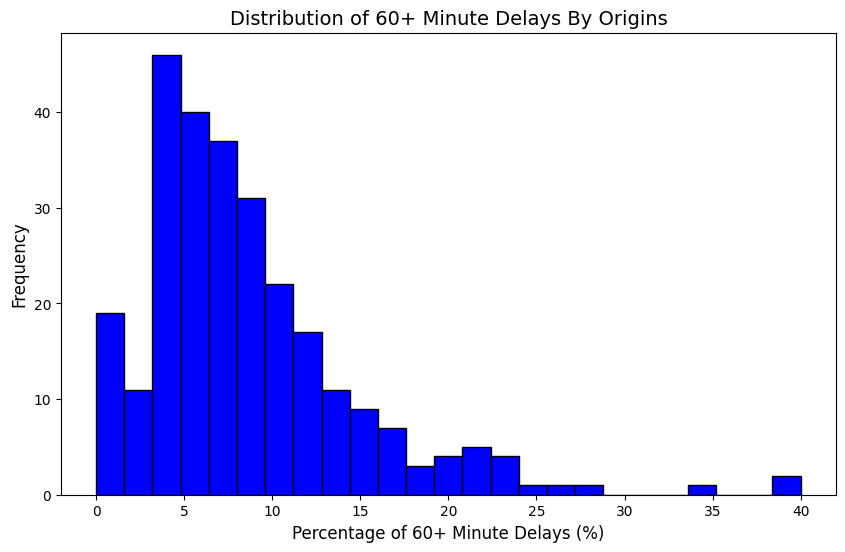

In [ ]:
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pct_delay_by_origin.values, bins=25, color='blue', edgecolor='black')

# Add labels and title
plt.title("Distribution of 60+ Minute Delays By Origins", fontsize=14)
plt.xlabel("Percentage of 60+ Minute Delays (%)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

In [ ]:
#initializing and fitting
xgb_model = xgb.XGBClassifier(random_state=0, eval_metric='logloss')
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#predicting the model
y_pred = xgb_model.predict(X_test)

In [ ]:
#evaluating the model
print("XGBoost Classifier (Baseline):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

XGBoost Classifier (Baseline):
Accuracy: 0.9246


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[134315,     68],
       [ 10887,     96]])

In [ ]:
# Predict probabilities for the test set (to calculate AUC)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # We need probabilities for the positive class

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7127


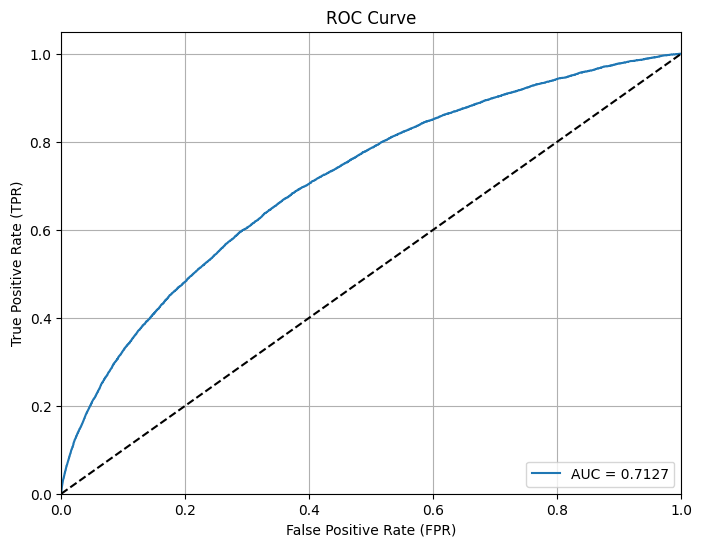

In [ ]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()